In [16]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# Load dataset

In [17]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "pororo")
qa_json_path = os.path.join(base_dir, "qa.json")
description_csv_path = os.path.join(base_dir, "descriptions.csv")
gif_paths = {}

def load_dataset(qa_json_path, description_csv_path):
    try:
        with open(qa_json_path, "r") as f:
            qa_data = json.load(f)["PororoQA"]
        descriptions = pd.read_csv(description_csv_path)
        return qa_data, descriptions
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], pd.DataFrame()

# TODO increase questions
def get_random_questions(qa_data, max_questions=40, base_pattern="Pororo_ENGLISH1", seed=42):
    random.seed(seed)

    # Filter all eligible questions
    filtered_questions = [q for q in qa_data if base_pattern in q["video_name"]]

    # Group by unique (video_name, supporting_num) pairs to avoid duplicates
    unique_pairs = {}
    for q in filtered_questions:
        key = (q["video_name"], q["supporting_num"])
        if key not in unique_pairs:
            unique_pairs[key] = []
        unique_pairs[key].append(q)

    # Sample from unique pairs
    unique_keys = list(unique_pairs.keys())
    selected_keys = random.sample(unique_keys, min(max_questions, len(unique_keys)))

    # Get one question from each selected pair
    sampled_questions = []
    episode_counts = {}

    for key in selected_keys:
        question = random.choice(unique_pairs[key])
        sampled_questions.append(question)
        episode = question["video_name"]
        episode_counts[episode] = episode_counts.get(episode, 0) + 1

    # Group by season for display
    season_episodes = {
        "Pororo_ENGLISH1_1": [],
        "Pororo_ENGLISH1_2": [],
        "Pororo_ENGLISH1_3": []
    }

    for ep in episode_counts.keys():
        season = "_".join(ep.split("_")[:3])
        if season in season_episodes:
            season_episodes[season].append(ep)

    print(f"\nSelected {len(sampled_questions)} questions from {len(episode_counts)} episodes:")
    for season in sorted(season_episodes.keys()):
        season_eps = {ep: episode_counts[ep] for ep in season_episodes[season]}
        if season_eps:
            print(f"\n{season}:")
            for ep in sorted(season_eps.keys()):
                print(f"  {ep}: {season_eps[ep]} questions")

    return sampled_questions

def get_seeded_question(questions, gif_num, base_seed=42):
    """Get deterministic random question for a GIF"""
    if not questions:
        return None
    local_random = random.Random(base_seed + gif_num)
    sorted_questions = sorted(questions, key=lambda x: x["qid"])
    return local_random.choice(sorted_questions)

def encode_gif(gif_path):
    try:
        if not os.path.exists(gif_path):
            print(f"Error: GIF not found at {gif_path}")
            return None
        with open(gif_path, "rb") as gif_file:
            image_base64 = base64.b64encode(gif_file.read()).decode('utf-8')
            return image_base64
    except Exception as e:
        print(f"Error encoding GIF: {e}")
        return None

# Load data
qa_data, descriptions = load_dataset(qa_json_path, description_csv_path)

# Get random sample of questions TODO increase number of questions
sampled_questions = get_random_questions(qa_data, max_questions=40)

# Group questions by supporting_num
grouped_questions = {}
for entry in sampled_questions:
    video_name = entry["video_name"]
    supporting_num = entry["supporting_num"]
    key = (video_name, supporting_num)
    if key not in grouped_questions:
        grouped_questions[key] = []
    grouped_questions[key].append(entry)

# Get unique pairs to process
gif_pairs = sorted(list(grouped_questions.keys()))
correct_count = 0
total_count = len(gif_pairs)

# Used to store question information for each GIF pair
question_data = {}
for video_name, gif_num in gif_pairs:
    current_questions = grouped_questions[(video_name, gif_num)]
    if current_questions:
        entry = get_seeded_question(current_questions, int(gif_num))

        question = entry["question"]
        correct_idx = entry["correct_idx"]
        answers = [entry[f"answer{i}"] for i in range(5)]
        correct_answer = answers[correct_idx]
        qid = entry["qid"]

        question_data[(video_name, gif_num)] = {
            'entry': entry,
            'question': question,
            'correct_answer': correct_answer,
            'qid': qid
        }

        # gif path
        episode_parts = video_name.split("_")
        episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
        gif_paths[(video_name, gif_num)] = os.path.join(episode_folder, f"{gif_num}.gif")

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Initializing the agents
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_HALLUCINATION_AGENT = False


Selected 40 questions from 22 episodes:

Pororo_ENGLISH1_1:
  Pororo_ENGLISH1_1_ep1: 1 questions
  Pororo_ENGLISH1_1_ep10: 2 questions
  Pororo_ENGLISH1_1_ep11: 1 questions
  Pororo_ENGLISH1_1_ep12: 4 questions
  Pororo_ENGLISH1_1_ep13: 2 questions
  Pororo_ENGLISH1_1_ep2: 4 questions
  Pororo_ENGLISH1_1_ep5: 1 questions
  Pororo_ENGLISH1_1_ep6: 4 questions
  Pororo_ENGLISH1_1_ep9: 1 questions

Pororo_ENGLISH1_2:
  Pororo_ENGLISH1_2_ep10: 1 questions
  Pororo_ENGLISH1_2_ep2: 2 questions
  Pororo_ENGLISH1_2_ep5: 2 questions
  Pororo_ENGLISH1_2_ep8: 3 questions

Pororo_ENGLISH1_3:
  Pororo_ENGLISH1_3_ep1: 1 questions
  Pororo_ENGLISH1_3_ep11: 1 questions
  Pororo_ENGLISH1_3_ep12: 2 questions
  Pororo_ENGLISH1_3_ep13: 1 questions
  Pororo_ENGLISH1_3_ep2: 1 questions
  Pororo_ENGLISH1_3_ep3: 1 questions
  Pororo_ENGLISH1_3_ep4: 1 questions
  Pororo_ENGLISH1_3_ep5: 2 questions
  Pororo_ENGLISH1_3_ep7: 2 questions


# Agents Configuration

In [18]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Visual agent: handles image-related tasks, and outputs image description
def visual_agent(image_base64, question, description, subtitles, max_retries=3, retry_delay=2):
    # If visual agent is disabled, return a basic placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from Pororo."
        
    prompt = f"""
    You are a cartoon visual analysis expert. Analyze the given image and generate a **concise and factual visual description**. 
    You are also provided with subtitles and a brief text description of the scene to help disambiguate the visual content. 
    However, your response must be based **only on what is visibly present in the image**. 
    Use the text information to avoid hallucination or misinterpretation, but do not repeat or paraphrase it.

    Task: Generate a short, grounded visual description based on the image and the context below.

    Remember to focus on visual elements that might help answer this specific question: 
    **{question}**
    
    Subtitles: {subtitles}
    Scene Description: {description}

    Strictly follow these guidelines:
    - Limit your description to **3–4 sentences maximum**
    - Use **simple, clear language** and avoid redundancy
    - Mention only:
        1. Characters: Visible characters with notable visual traits
        2. Actions: What they are doing (body posture, gestures)
        3. Scene: Indoor/outdoor, main environment
        4. Key Objects: Only if directly relevant (e.g., items being used or interacted with)
        5. Positions: Where things are (e.g., "on the left", "in the background")

    Do not include:
    - Opinions, guesses, or emotions
    - Storyline interpretation or external context
    - Unnecessary details (e.g., background clutter)

    Be concise. Stay grounded in what is visible only.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1500,
                    temperature=0.1
                )
                visual_desc = completion.choices[0].message.content.strip()
                return visual_desc
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/gif",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1500,
                    temperature=0.1,
                )
                visual_desc = completion.content[0].text.strip()
                return visual_desc

        except Exception as e:
            print(f"Visual agent attempt {attempt+1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return "Error: Unable to analyze the image after multiple attempts."

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_desc, description, subtitles, max_retries=3, retry_delay=2):
    # If language agent is disabled but this function is still called, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None

    # Note: visual_desc is always available regardless of whether visual agent is enabled or not
    # - If visual agent is enabled: visual_desc contains the generated description
    # - If visual agent is disabled: visual_desc contains "This is a cartoon image from Pororo."
    prompt = f"""
    As a cartoon language analysis expert, provide a concise and accurate answer to the question based on the available information using EXACTLY ONE SENTENCE within 30 words.

    Input:
    Relevant Question/task: {question}
    Scene Description: {description}
    Visual Description: {visual_desc}
    Subtitles: {subtitles}

    Guidelines:
    1. No explanations allowed.
    2. Response must be in English only. DO NOT include text in any other language.
    3. Avoid phrases like "based on ...", "according to..." or "the description prided..."   
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,  
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url":
                                        {"url": f"data:image/gif;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=50,
                    temperature=0.1,
                )
                initial_predicted_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=50,
                    temperature=0.1,
                )
                initial_predicted_answer = completion.content[0].text.strip().lower()

            # Extract first sentence
            sentences = re.split(r'[.!?]', initial_predicted_answer)
            first_sentence = sentences[0].strip()

            # Skip empty sentences
            if not first_sentence and len(sentences) > 1:
                first_sentence = next((s.strip() for s in sentences if s.strip()), "")

            return first_sentence

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

# Hallucination detection agent: implement as a Critic agent that evaluates and potentially corrects answers
def hallucination_agent(question, image_base64, initial_predicted_answer, visual_desc, description, subtitles, max_retries=3, retry_delay=2):
    # If hallucination agent is disabled, return the initial prediction
    if not ENABLE_HALLUCINATION_AGENT:
        return initial_predicted_answer

    # Handle case when language_agent failed or was disabled
    if initial_predicted_answer is None:
        return "unknown"
        
    # Skip if initial answer is very short (likely to be correct in its simplicity)
    if len(initial_predicted_answer.split()) <= 3:
        return initial_predicted_answer.lower()
        
    # Implementing Critic Agent based on "Critic-V: VLM Critics Help Catch VLM Errors in Multimodal Reasoning"
    prompt = f"""
    As a cartoon critical analysis expert, your task is to evaluate and potentially improve the answer to a cartoon-related question.
    
    Input:
    Question: {question}
    Scene Description: {description}
    Dialogue/Subtitles: {subtitles}
    Image Context: {visual_desc}
    Proposed Answer: {initial_predicted_answer}
    
    CRITIC EVALUATION PROCEDURE:
    1. CAREFULLY analyze the question to identify exactly what information is being requested
    2. IDENTIFY key elements in the scene description and dialogue that specifically answer the question
    3. EVALUATE how well the proposed answer addresses the exact question asked
    4. CHECK for any factual inconsistencies between the proposed answer and the supporting materials
    5. Consider if the answer is unnecessarily complex, ambiguous, or contains irrelevant information
    
    DECISION FRAMEWORK:
    - For questions about SPECIFIC EVENTS: Focus on exactly what happened, with minimal interpretation
    - For questions about CHARACTER SPEECH: Prioritize exact quotes from the dialogue when possible
    - For questions about OBJECTS/ENTITIES: Be precise about what was visibly present
    - For YES/NO questions: Ensure the core yes/no part is clearly stated first
    
    RESPOND with one of the following:
    KEEP: The answer directly addresses the question with accurate information
    REVISE: [concise corrected answer] - If the answer needs focused improvement
    
    REVISION PRINCIPLES:
    - Prioritize CONCISENESS - remove unnecessary explanations or details
    - Ensure FACTUAL ACCURACY based on the provided context
    - Match the STYLE AND TONE of the reference answers (simple, direct statements)
    - For YES/NO questions, start with "yes" or "no" followed by minimal supporting detail
    """
    
    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,  
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url", 
                             "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.1,
                )
                response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image", 
                             "source": {
                                 "type": "base64",
                                 "media_type": "image/gif",
                                 "data": image_base64
                             }}
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.1,
                )
                response = completion.content[0].text.strip()
            
            # Process the response to extract the decision and potential revision
            if response.upper().startswith("KEEP"):
                # Keep original answer
                return initial_predicted_answer.lower()
            elif response.upper().startswith("REVISE:"):
                # Extract revised answer
                revised_answer = response[7:].strip()  # Remove "REVISE: " prefix
                
                # Take just the first sentence of the revision to maintain consistency with language agent
                sentences = re.split(r'[.!?]', revised_answer)
                first_sentence = sentences[0].strip().lower() if sentences else ""
                
                # Only use the revised answer if it's not empty and substantial
                if first_sentence and len(first_sentence) >= 5:
                    return first_sentence
                    
            # Default to original if format is unclear or revision is too short
            return initial_predicted_answer.lower()

        except Exception as e:
            print(f"Critic agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue
    
    # If all retry attempts fail, return the initial prediction
    return initial_predicted_answer.lower()

Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [19]:
def compute_accuracy(question, correct_answer, predicted_answer, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.0, [1.0] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Correct Answer: {correct_answer}
        Predicted Answer: {predicted_answer}

        Evaluation Rules:
        1. Focus PRIMARILY on semantic equivalence.
        2. Additional details should NEVER reduce the score if core information is correct.
        3. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering

        Scoring Examples:
        - Example of Score 1.0 (Perfect match or semantic equivalence):
        Question: "how did pororo feel after seeing that the flower has wilted"
        Correct: "he was very upset"
        Predicted: "pororo felt sad after seeing that the flower had wilted"
        Score: 1.0 (Synonyms with same core meaning)

        - Example of Score 1.0 (Additional details):
        Question: "what does crong do when pororo says 'come here'"
        Correct: "crong runs away from pororo"
        Predicted: "when pororo says 'come here,' crong tries to run away again"
        Score: 1.0 (Contains core information with additional details)

        - Example of Score 0.75 (Mostly correct but missing or slightly inaccurate information):
        Question: "what did loopy propose to the group after telling them about the flower"
        Correct: "loopy proposed that they should ask her anything"
        Predicted: "loopy proposed to the group that they ask the magic flower questions to predict the future"
        Score: 0.75 (Core action correct but adds slight inaccuracy about asking the flower directly)

        - Example of Score 0.5 (Partially correct):
        Question: "what does pororo almost forget to leave with poby"
        Correct: "the broken camera piece"
        Predicted: "pororo almost forgets to leave with poby's precious camera"
        Score: 0.5 (Mentions camera but misses the specific detail that it's broken)

        - Example of Score 0.25 (Slightly correct):
        Question: "what does eddy ask pororo"
        Correct: "he asks pororo what are you doing"
        Predicted: "eddy asks crong why pororo is acting so urgently"
        Score: 0.25 (Wrong recipient but related to pororo's actions)

        - Example of Score 0.0 (Completely incorrect):
        Question: "what was crong playing with as pororo entered the house"
        Correct: "crong was playing with a snowboard"
        Predicted: "crong was not shown playing with anything"
        Score: 0.0 (Directly contradicts the correct answer)
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.1
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.1,
                    )
                    response = completion.content[0].text.strip()

                # Extract numeric score using regex
                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0.0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiments

In [20]:
# Define the configurations to test
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'hallucination': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'hallucination': False,
        'name': 'visual_language'
    },
    #  Language + Hallucination agents
    {
        'visual': False,
        'language': True,
        'hallucination': True,
        'name': 'language_hallucination'
    },
    # Visual + Language + Hallucination agents (all enabled)",
    {
        'visual': True,
        'language': True,
        'hallucination': True,
        'name': 'visual_language_hallucination'
    }
]

def run_experiment(enable_visual, enable_language, enable_hallucination, max_questions=40):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_HALLUCINATION_AGENT

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'hallucination': ENABLE_HALLUCINATION_AGENT
    }

    # Set configuration for this experiment
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_HALLUCINATION_AGENT = enable_hallucination

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_hallucination:
        config_parts.append("hallucination")
    
    config_suffix = "_".join(config_parts)

    # Initialize results for this experiment
    results = []
    correct_count = 0
    accuracies = []
    total_processed = 0

    column_order = [
        'row_num',
        'video_name', 
        'gif_num',
        'qid',
        'question',
        'correct_answer',
        'visual_desc',
        'initial_predicted_answer',
        'predicted_answer',
        'evaluator_scores',
        'accuracy'
    ]

    try:
        # Select question set to process
        pairs_to_process = gif_pairs[:max_questions]

        # Process each video and GIF pair
        for idx, (video_name, gif_num) in enumerate(tqdm(pairs_to_process), 1):
            # Skip if no question data available
            if (video_name, gif_num) not in question_data:
                print(f"No question data found for {video_name} GIF {gif_num}")
                continue
                
            # Get question information
            q_info = question_data[(video_name, gif_num)]
            question = q_info['question']
            correct_answer = q_info['correct_answer']
            qid = q_info['qid']
            
            # Get gif path and resources
            gif_path = gif_paths[(video_name, gif_num)]
            gif_directory = os.path.dirname(gif_path)
            
            # Load subtitles
            try:
                with open(os.path.join(gif_directory, "subtitles.txt"), "r") as f:
                    subtitles = f.read()
            except FileNotFoundError:
                subtitles = ""

            # Get description
            description_rows = descriptions.loc[
                (descriptions.iloc[:, 0] == video_name) &
                (descriptions.iloc[:, 1] == int(gif_num))
            ]
            if description_rows.empty:
                print(f"Description for {video_name} GIF {gif_num} not found")
                continue

            descriptions_list = description_rows.iloc[:, 2].tolist()
            description = " ".join(descriptions_list)
            
            # Encode GIF to base64
            image_base64 = encode_gif(gif_path)
            if not image_base64:
                print(f"Error: Failed to encode GIF {gif_num}")
                continue
            
            # Get visual description (will be placeholder if visual agent disabled)
            visual_desc = visual_agent(image_base64, question=question, description=description, subtitles=subtitles)
            if visual_desc is None:
                print(f"Error: Visual agent failed to process GIF {gif_num}")
                continue

            # Handle prediction based on enabled agents
            if enable_language:
                # Get language agent prediction
                initial_predicted_answer = language_agent(question, image_base64, visual_desc, description, subtitles)
                if initial_predicted_answer is None:
                    print(f"Error for question {qid} - Failed to generate answer")
                    continue
                
                # Get hallucination agent improvement if enabled
                if enable_hallucination:
                    final_answer = hallucination_agent(
                        question=question,
                        image_base64=image_base64,
                        initial_predicted_answer=initial_predicted_answer,
                        visual_desc=visual_desc,
                        description=description,
                        subtitles=subtitles
                    )
                    predicted_answer = final_answer if final_answer else initial_predicted_answer
                else:
                    predicted_answer = initial_predicted_answer
            else:
                # Visual-only mode: extract answer from visual description
                sentences = re.split(r'[.!?]', visual_desc)
                short_desc = ". ".join(s.strip() for s in sentences[:2] if s.strip())
                predicted_answer = short_desc[:100] if short_desc else "unknown"
                initial_predicted_answer = predicted_answer  # Set initial_predicted_answer the same as predicted_answer in this case
            
            # Calculate accuracy
            is_correct, scores = compute_accuracy(question, correct_answer, predicted_answer)
            correct_count += is_correct
            accuracies.append(is_correct)
            total_processed += 1
            
            # Store result
            result = {
                'gif_num': gif_num,
                'video_name': video_name,
                'qid': qid,
                'question': question,
                'correct_answer': correct_answer,
                'visual_desc': visual_desc,
                'initial_predicted_answer': initial_predicted_answer,
                'predicted_answer': predicted_answer,
                'evaluator_scores': ','.join([str(score) for score in scores]) if scores else '',
                'accuracy': is_correct
            }
            results.append(result)

            print(f"Video name: {video_name}")
            print(f"GIF number: {gif_num}")
            print(f"QID: {qid}")
            print(f"Question: {question}")
            print(f"Correct Answer: {correct_answer}")
            
            # Only display visual description if visual agent is enabled
            if enable_visual:
                print(f"Visual Description: {visual_desc}")
            
            # Only display initial answer if language agent is enabled and there's a distinction between initial and final answers
            if enable_language and enable_hallucination:
                print(f"Initial Answer: {initial_predicted_answer}")
                print(f"Predicted Answer: {predicted_answer}")
            else:
                print(f"Predicted Answer: {predicted_answer}")
                
            print(f"Evaluator Scores: {scores}")
            print(f"Accuracy: {is_correct:.4f}\n")

        # Calculate overall accuracy
        accuracy = sum(accuracies) / len(accuracies) if accuracies else 0
        print(f"\nOverall Accuracy: {accuracy:.4f}")
        
        # Save results - using the existing save_results section
        # Clean up ablation results to remove any existing average rows
        results_to_save = [r for r in results if r.get('gif_num') != 'Average']
        
        # Add row numbers to each result
        for i, result in enumerate(results_to_save, 1):
            result['row_num'] = i

        safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
        results_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
        
        # Save to ablation subdirectory with configuration in filename
        output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_suffix}_{safe_model_name}.csv')
        
        # Convert to DataFrame and save with error handling
        try:
            results_df = pd.DataFrame(results_to_save)
            # Make sure all required columns exist
            for col in column_order:
                if col not in results_df.columns:
                    results_df[col] = ''
                    
            results_df = results_df[column_order]
            results_df.to_csv(output_path, index=False)
            print(f"Results successfully saved to: {output_path}")
        except Exception as e:
            print(f"Error saving results to CSV: {e}")
        
        return results, accuracy

    except Exception as e:
        print(f"Error in {config_suffix} configuration: {e}")
        return [], 0.0
    finally:
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_HALLUCINATION_AGENT = original_config['hallucination']

# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

print(f"Total number of sampled questions: {len(gif_pairs)}")

for config in configurations:
    print(f"\n{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config['visual'],
        enable_language=config['language'],
        enable_hallucination=config['hallucination'],
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue
    print(f"Configuration {config['name']} finished. Number of questions: {len(results)}, Accuracy: {accuracy:.4f}")
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results

Total number of sampled questions: 40

Running configuration: language


  2%|▎         | 1/40 [00:21<14:12, 21.86s/it]

Video name: Pororo_ENGLISH1_1_ep1
GIF number: 14
QID: 383
Question: whtat does eddy ask pororo
Correct Answer: he asks pororo what are you doing
Predicted Answer: eddy asks crong why pororo is acting urgently
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500



  5%|▌         | 2/40 [00:35<10:55, 17.25s/it]

Video name: Pororo_ENGLISH1_1_ep10
GIF number: 12
QID: 1100
Question: were eddy's friends interested seeing his new toy?
Correct Answer: yes, they ran happily towards the new toy.
Predicted Answer: yes, eddy's friends were interested in seeing his new toy, as they expressed excitement about it and planned to ride in it together
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000



...

Video name: Pororo_ENGLISH1_3_ep5
GIF number: 25
QID: 2333
Question: does the friends find pororo behind the snow man?
Correct Answer: the friends find pororo behind the snow man.
Visual Description: The scene is set in a snowy outdoor environment with evergreen trees in the background. Visible characters include Loopy, a pink otter; Poby, a white bear; Crong, a green dinosaur; and Eddy, an orange fox. They are standing together, facing forward, with cheerful expressions and gestures, as if waving or saying goodbye. There is no indication of Pororo being present or hidden behind a snowman in this image.
Initial Answer: no, the friends do not find pororo behind the snowman; they are waving goodbye to him instead
Predicted Answer: no, the friends do not find pororo behind the snowman; they are waving goodbye to him
Evaluator Scores: [0.0, 0.0, 0.0]
Accuracy: 0.0000



 98%|█████████▊| 39/40 [16:28<00:10, 10.56s/it]

Video name: Pororo_ENGLISH1_3_ep7
GIF number: 25
QID: 2425
Question: what does crong do when pororo says "come here"
Correct Answer: crong runs away from pororo
Visual Description: In the snowy outdoor scene, Pororo, a small blue penguin wearing a brown aviator hat and orange goggles, stands with his hands on his hips, looking assertive. He is facing Crong, a small green dinosaur, who appears to be trying to run away. The background features a brown house and green trees under a blue sky. Crong's body posture suggests he is hesitant or playful, indicating he is not complying with Pororo's request to come over.
Initial Answer: when pororo says "come here," crong tries to run away, indicating his playful reluctance to comply with pororo's request
Predicted Answer: when pororo says "come here," crong playfully tries to run away, showing his reluctance to comply
Evaluator Scores: [0.75, 0.75, 0.75]
Accuracy: 0.7500



100%|██████████| 40/40 [16:36<00:00, 24.92s/it]

Video name: Pororo_ENGLISH1_3_ep7
GIF number: 47
QID: 2446
Question: what does poby say when invited to play
Correct Answer: he says "of course"
Visual Description: In the image, a white bear, Poby, is seen walking on a snowy path surrounded by green trees under a blue sky. He has a cheerful posture with his arms raised, indicating excitement. The scene is outdoors, showcasing a winter landscape. Poby appears to be heading towards his friends to join in their activities.
Initial Answer: poby enthusiastically responds, "of course," when invited to play with his friends
Predicted Answer: poby responds, "of course," when invited to play with his friends
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000


Overall Accuracy: 0.6438
Results successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_hallucination_gpt_4o_mini.csv
Configuration visual_language_hallucination finished. Number of questions: 40, Accuracy: 0.6438


# Save results

In [22]:
# Clean up ablation results to remove any existing average rows
results_ablation = [r for r in results_ablation if r['gif_num'] != 'Average']

# Get unique videos and questions
unique_videos = len(set(r['video_name'] for r in results_ablation))
unique_questions = len(set(r['qid'] for r in results_ablation))

average_accuracy = sum(r['accuracy'] for r in results_ablation) / len(results_ablation) if results_ablation else 0

# Add row numbers to each result
for i, result in enumerate(results_ablation, 1):
    result['row_num'] = i

# Add average accuracy as the last row
average_result = {
    'row_num': len(results_ablation) + 1,
    'video_name': f'Total Videos: {unique_videos}',
    'gif_num': 'Average',
    'qid': '',
    'question': f'Total Questions: {unique_questions}',
    'correct_answer': '',
    'predicted_answer': '',
    'evaluator_scores': '',  
    'accuracy': average_accuracy
}
results_ablation.append(average_result)

column_order = [
    'row_num',
    'video_name', 
    'gif_num',
    'qid',
    'question',
    'correct_answer',
    'visual_desc',
    'initial_predicted_answer',
    'predicted_answer',
    'evaluator_scores',
    'accuracy'
]

safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
results_dir = os.path.join(os.getcwd(), "results")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)

# Create configuration name for the file suffix
config_parts = []
if ENABLE_VISUAL_AGENT:
    config_parts.append("visual")
if ENABLE_LANGUAGE_AGENT:
    config_parts.append("language")
if ENABLE_HALLUCINATION_AGENT:
    config_parts.append("hallucination")

# Only proceed if at least one agent is enabled
if not config_parts:
    print("No agents enabled, skipping results save.")
else:
    config_suffix = "_".join(config_parts)

    # Save to ablation subdirectory with configuration in filename
    output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_suffix}_{safe_model_name}.csv')
    
    # Check if the file exists and explicitly remove it
    if os.path.exists(output_path):
        try:
            os.remove(output_path)
            print(f"Existing file removed: {output_path}")
        except Exception as e:
            print(f"Error removing existing file: {e}")
    
    # Convert to DataFrame and save with error handling
    try:
        results_df = pd.DataFrame(results_ablation)
        results_df = results_df[column_order]
        
        # Save with explicit file opening to ensure it closes properly
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results successfully saved to: {output_path}")
        else:
            print(f"Warning: File was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results to CSV: {e}")

No agents enabled, skipping results save.


# Visualization and Comparison

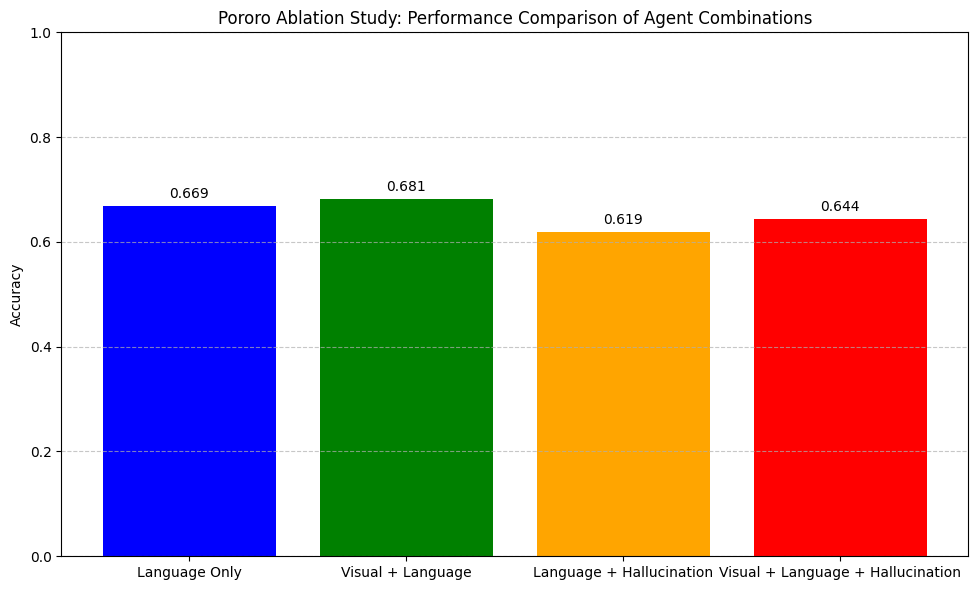

Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_comparison.csv


In [23]:
# Create visualization of ablation results
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Hallucination": all_accuracies.get('language_hallucination', 0),
    "Visual + Language + Hallucination": all_accuracies.get('visual_language_hallucination', 0)
}

plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Pororo Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
comparison_path = os.path.join(os.getcwd(), "results", "ablation", "pororo_ablation_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison results saved to: {comparison_path}")